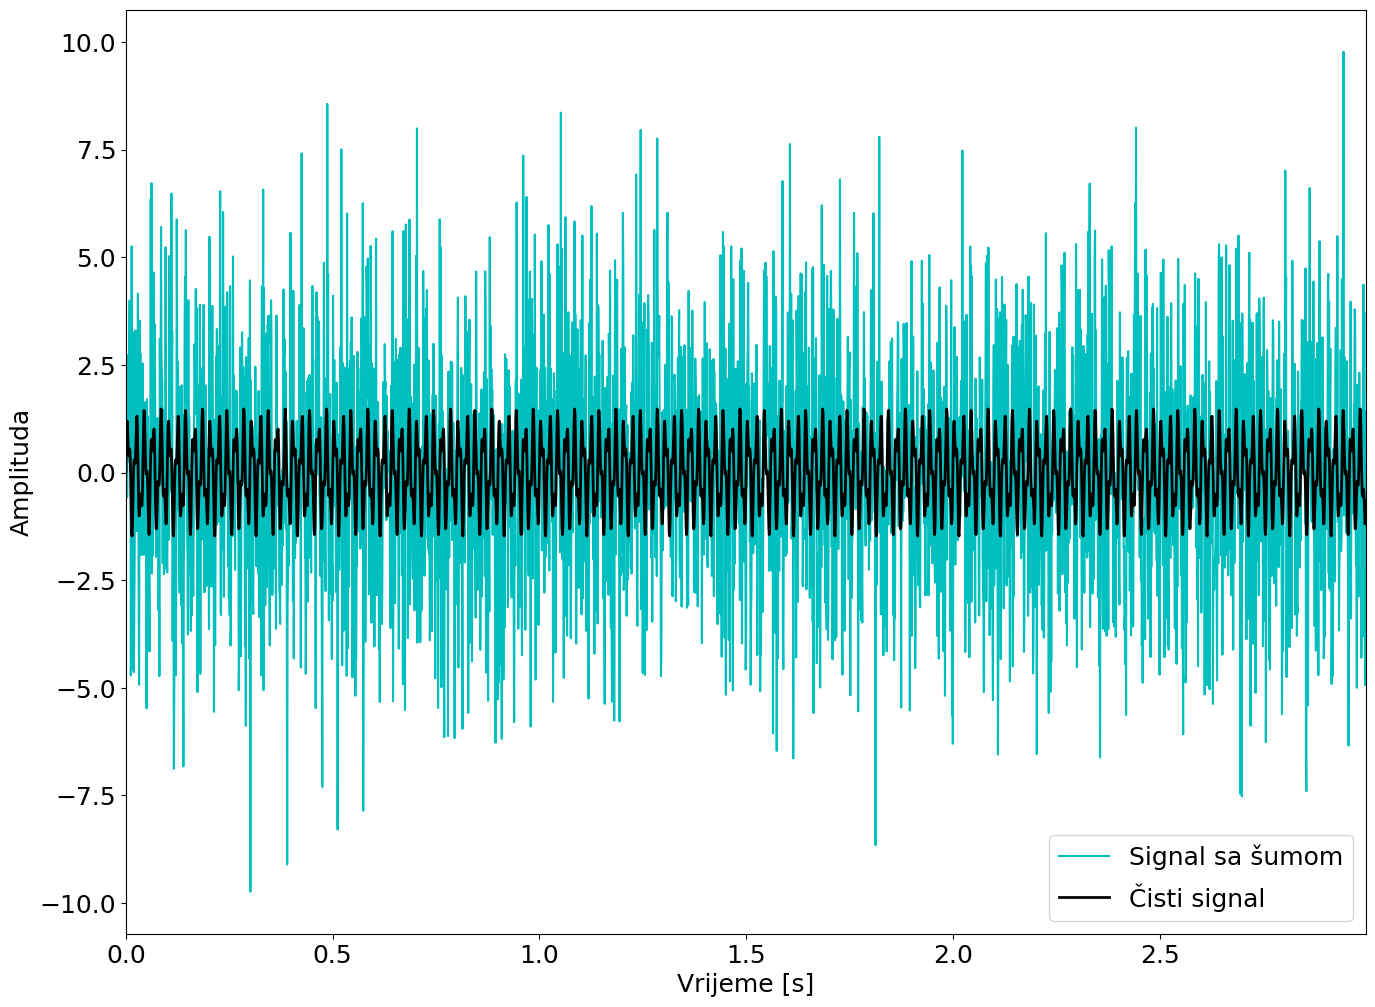

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams.update({'font.size': 18})

# Napravimo jednostavan signal sa dvije frekvencije
dt = 0.001 # vremenski korak od 1 ms
t = np.arange(0, 3, dt) # vrijeme od 0 do 3 sekunde, korak je 0.001 znaci imamo 3000 uzoraka
f = 1 * np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 120 * t) # suma dvije frekvencije
f_clean = f
f = f + 2.5 * np.random.randn(len(t))  # dodajemo šum

plt.plot(t, f, color='c', linewidth=1.5, label='Signal sa šumom')
plt.plot(t, f_clean, color='k', linewidth=2, label='Čisti signal')
plt.xlim(t[0], t[-1])
plt.xlabel('Vrijeme [s]')
plt.ylabel('Amplituda')
plt.legend()

/Users/dtx/Git/dyna-ai/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/dtx/Git/dyna-ai/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


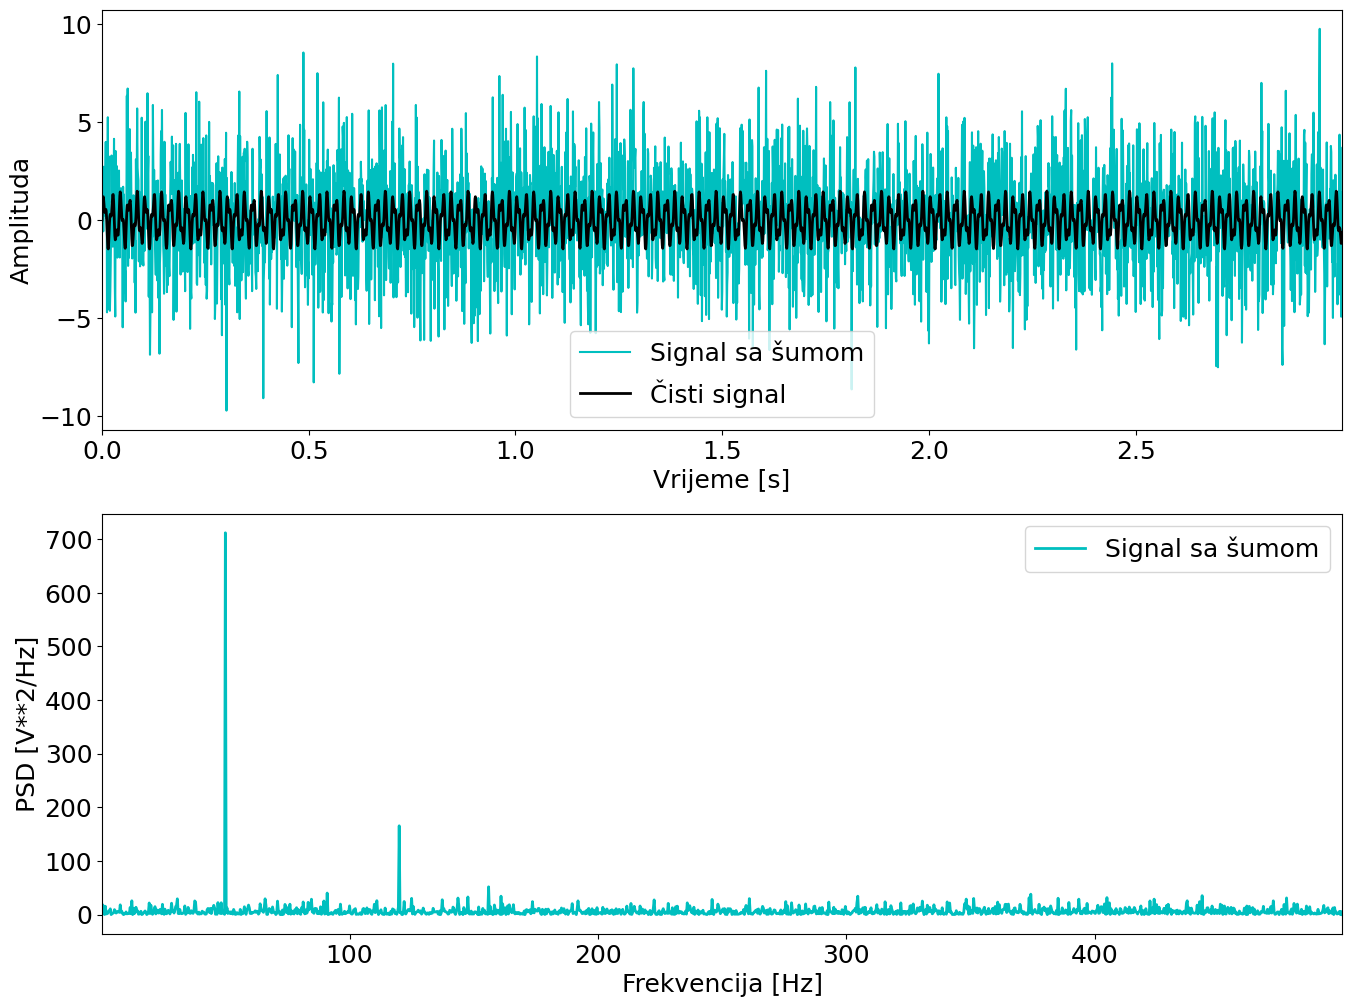

In [2]:
## Izracunamo FFT

n = len(t)
fhat = np.fft.fft(f, n)  # izracunamo FFT
PSD = fhat * np.conj(fhat) / n  # izracunamo Power Spectrum Density
freq = (1/(dt*n)) * np.arange(n)  # x-os frekvencija
L = np.arange(1, np.floor(n/2), dtype='int')  # uzimamo samo polovinu spektra, druga polovina je simetricna

fig, axs = plt.subplots(2, 1)

plt.sca(axs[0])
plt.plot(t, f, color='c', linewidth=1.5, label='Signal sa šumom')
plt.plot(t, f_clean, color='k', linewidth=2, label='Čisti signal')
plt.xlim(t[0], t[-1])
plt.xlabel('Vrijeme [s]')
plt.ylabel('Amplituda')
plt.legend()

plt.sca(axs[1])
plt.plot(freq[L], PSD[L], color='c', linewidth=2, label='Signal sa šumom')
plt.xlim(freq[L[0]], freq[L[-1]])
plt.xlabel('Frekvencija [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.legend()

plt.show()

In [3]:
# Koristimo PSD da filtriramo signal i uklonimo šum
indices = PSD > 100  # threshold za filtriranje
PSDclean = PSD * indices  # Nuliramo sve vrijednosti ispod threshold-a
fhat = indices * fhat  # Nuliramo sve male vrijednosti u FFT
ffilt = np.fft.ifft(fhat)  # Inverse FFT da dobijemo filtrirani signal

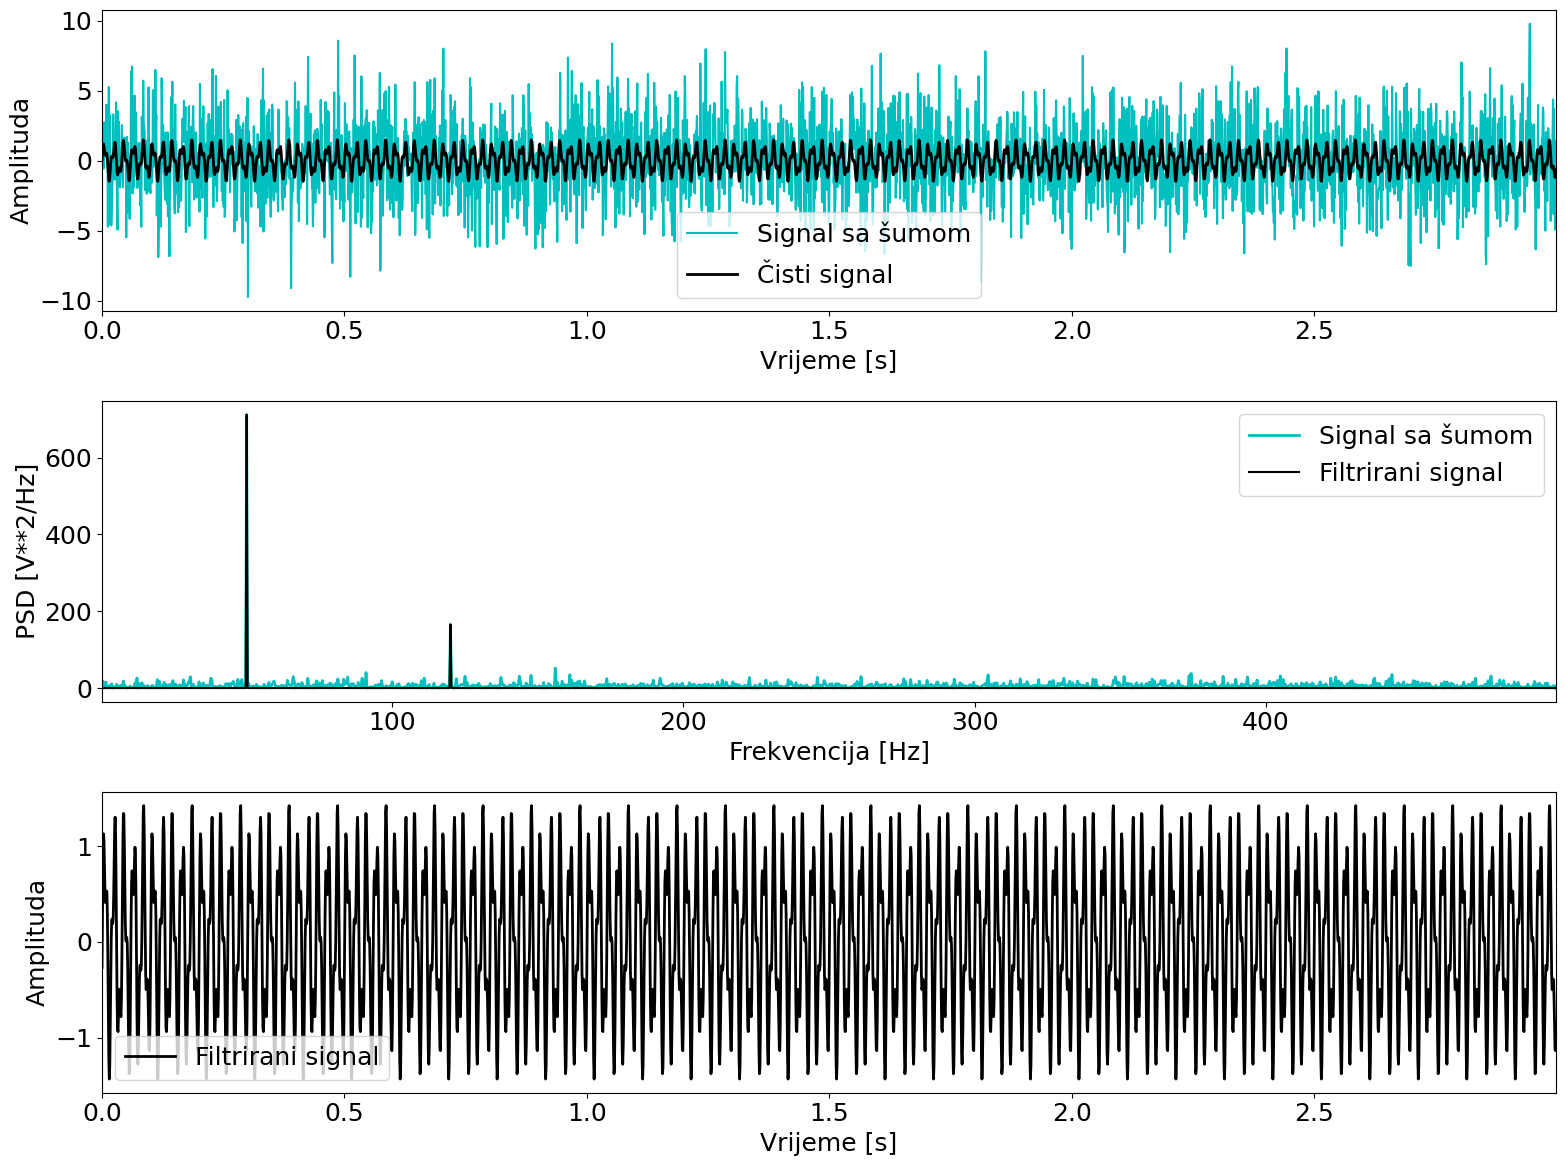

In [4]:
## Plotovi
fig, axs = plt.subplots(3, 1)

plt.sca(axs[0])
plt.plot(t, f, color='c', linewidth=1.5, label='Signal sa šumom')
plt.plot(t, f_clean, color='k', linewidth=2, label='Čisti signal')
plt.xlim(t[0], t[-1])
plt.xlabel('Vrijeme [s]')
plt.ylabel('Amplituda')
plt.legend()

plt.sca(axs[1])
plt.plot(freq[L], PSD[L], color='c', linewidth=2, label='Signal sa šumom')
plt.plot(freq[L], PSDclean[L], color='k', linewidth=1.5, label='Filtrirani signal')
plt.xlim(freq[L[0]], freq[L[-1]])
plt.xlabel('Frekvencija [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.legend()

plt.sca(axs[2])
plt.plot(t, ffilt, color='k', linewidth=2, label='Filtrirani signal')
plt.xlim(t[0], t[-1])
plt.xlabel('Vrijeme [s]')
plt.ylabel('Amplituda')
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
## Izvlacenje znacajki za ML

# RMS - energija
rms = np.sqrt(np.mean(f**2)) # Root Mean Square - koristi amplitudu (od osnovnih znacajki zvuka)
print("RMS:", rms)

# ZCR - koliko puta signal prelazi nulu, koristi promjene signala, frekvencijsku dinamiku (od osnovnih znacajki zvuka)
zcr = np.mean(np.abs(np.diff(np.sign(f))) / 2)

# Spectral Centroid - koristi frekvencije + amplitudu od osnovnih znacajki zvuka
spectral_centroid = np.sum(freq[L] * PSD[L]) / np.sum(PSD[L])
print("Spectral Centroid:", spectral_centroid)

# Spectral Bandwidth - koristi frekvencije + amplitudu od osnovnih znacajki zvuka
spectral_bandwidth = np.sqrt(np.sum(((freq[L] - spectral_centroid) ** 2) * PSD[L]) / np.sum(PSD[L]))
print("Spectral Bandwidth:", spectral_bandwidth)

# Spectral Roll-off - koristi frekvencije + amplitudu od osnovnih znacajki zvuka
commulative_energy = np.cumsum(PSD[L])
total_energy = commulative_energy[-1]
rolloff_threshold = 0.85 * total_energy

spectral_rolloff = freq[L][np.where(commulative_energy >= rolloff_threshold)[0][0]]
print("Spectral Roll-off:", spectral_rolloff)

# Spectral Flux - koristi promjene u frekvencijama + amplitudu od osnovnih znacajki zvuka
print("Spectral Flux: pogledaj dolje, podijelimo na vremenske prozore, za svaki prozor racunamo FFT i onda gledamo promjene u frekvencijama kroz vrijeme, najbolje pokazati u grafu")


# MFCC - treba nam i FFT i spektogram
import librosa
f_float = np.array(f, dtype=np.float32)  # Pretvaramo signal u float32
sr = int(1/dt)  # Sampling rate jer dt=0.001 --> fs = 1000 Hz
mfcss = librosa.feature.mfcc(y=f_float, sr=sr, n_mfcc=13, n_fft=256)  # MFCC - koristi frekvencije + amplitudu od osnovnih znacajki zvuka
print("MFCC shape:", mfcss.shape)



RMS: 2.628350548692835
Spectral Centroid: (237.1782055054482-9.51405834503272e-18j)
Spectral Bandwidth: (148.71537428479564+7.548042770949568e-17j)
Spectral Roll-off: 418.66666666666663
Spectral Flux: pogledaj dolje, podijelimo na vremenske prozore, za svaki prozor racunamo FFT i onda gledamo promjene u frekvencijama kroz vrijeme, najbolje pokazati u grafu


/Users/dtx/Git/dyna-ai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MFCC shape: (13, 6)


RMS: 2.628350548692835


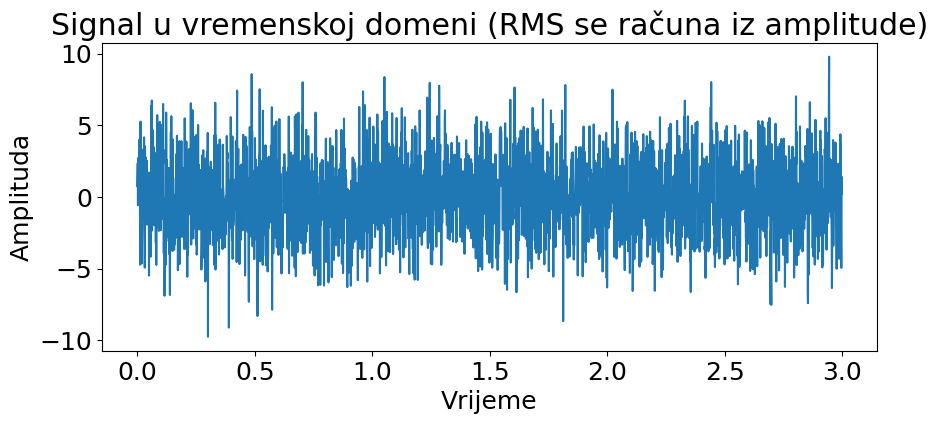

In [6]:
# Vizualizacija RMS-a

rms = np.sqrt(np.mean(f**2))
print("RMS:", rms)

plt.figure(figsize=(10,4))
plt.plot(t, f)
plt.title("Signal u vremenskoj domeni (RMS se računa iz amplitude)")
plt.xlabel("Vrijeme")
plt.ylabel("Amplituda")
plt.show()

ZCR: 0.4728242747582527


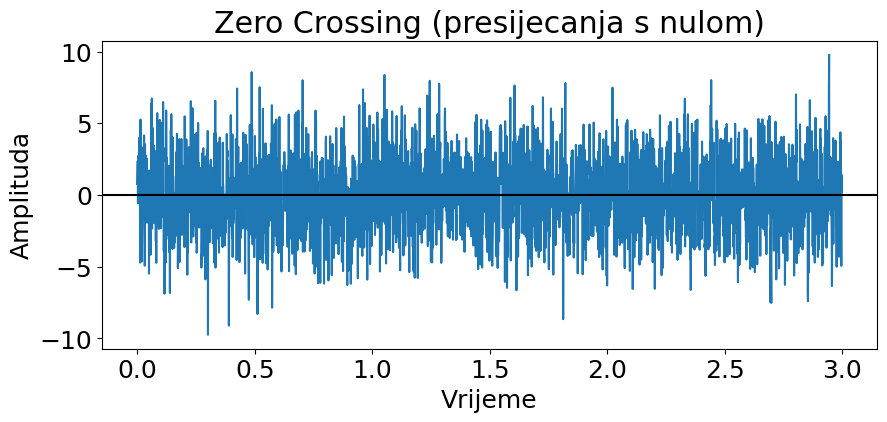

In [7]:
# Vizualizacija ZCR-a

zcr = np.mean(np.abs(np.diff(np.sign(f))) / 2)
print("ZCR:", zcr)

plt.figure(figsize=(10,4))
plt.plot(t, f)
plt.axhline(0, color='black')
plt.title("Zero Crossing (presijecanja s nulom)")
plt.xlabel("Vrijeme")
plt.ylabel("Amplituda")
plt.show()

Spectral Centroid: (237.1782055054482-9.51405834503272e-18j)


/Users/dtx/Git/dyna-ai/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/dtx/Git/dyna-ai/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


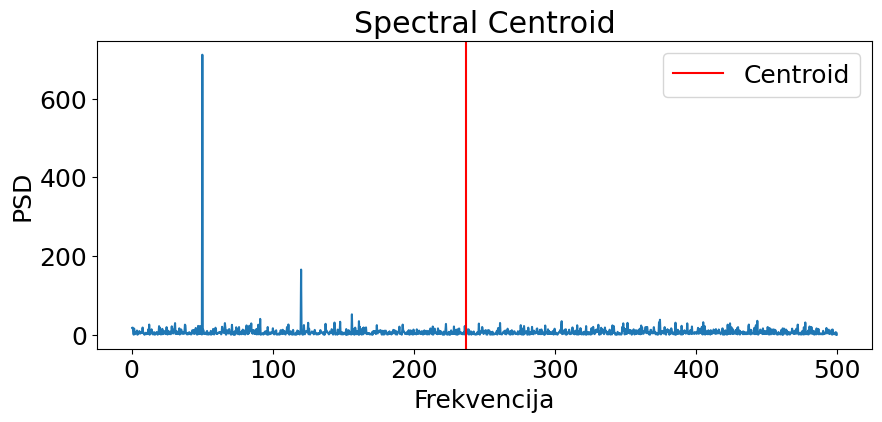

In [8]:
# Vizualizacija Spectral Centroid-a

spectral_centroid = np.sum(freq[L] * PSD[L]) / np.sum(PSD[L])
print("Spectral Centroid:", spectral_centroid)

plt.figure(figsize=(10,4))
plt.plot(freq[L], PSD[L])
plt.axvline(np.real(spectral_centroid), color='r', label='Centroid')
plt.legend()
plt.title("Spectral Centroid")
plt.xlabel("Frekvencija")
plt.ylabel("PSD") # power spectrum density
plt.show()

Spectral Bandwidth: (148.71537428479564+7.548042770949568e-17j)


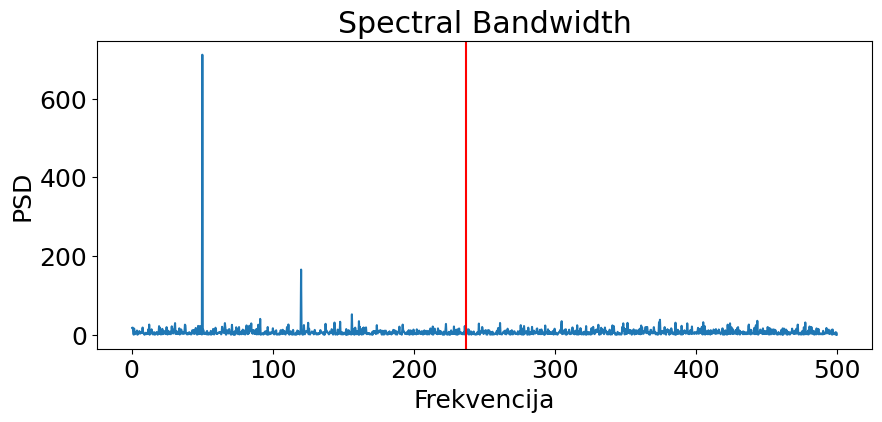

In [9]:
# Vizualizacija Spectral Bandwidth-a

spectral_bandwidth = np.sqrt(np.sum(((freq[L] - spectral_centroid) ** 2) * PSD[L]) / np.sum(PSD[L]))
print("Spectral Bandwidth:", spectral_bandwidth)

plt.figure(figsize=(10,4))
plt.plot(freq[L], PSD[L])
plt.axvline(np.real(spectral_centroid), color='r')
plt.title("Spectral Bandwidth") #  (prosjecno odstupanje frekvencija od centroida)
plt.xlabel("Frekvencija")
plt.ylabel("PSD") # power spectrum density
plt.show()

Spectral Roll-off: 470.0


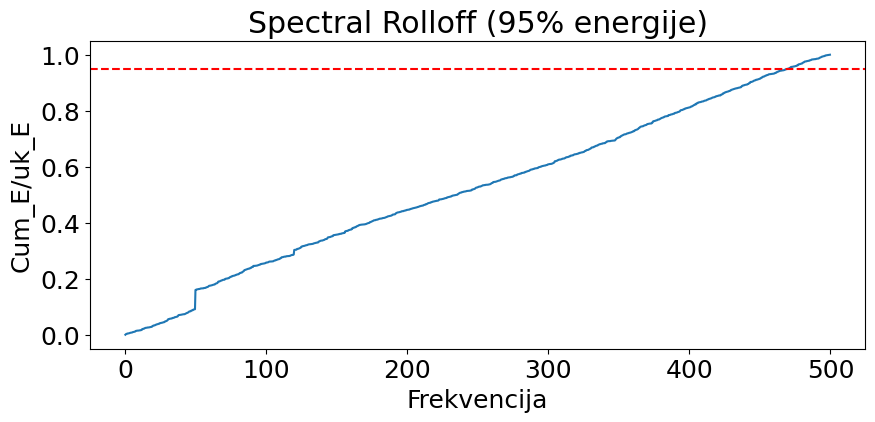

In [10]:
# Vizualizacija Spectral Roll-off-a

commulative_energy = np.cumsum(PSD[L])
total_energy = commulative_energy[-1]
rolloff_threshold = 0.95 * total_energy
spectral_rolloff = freq[L][np.where(commulative_energy >= rolloff_threshold)[0][0]]
print("Spectral Roll-off:", spectral_rolloff)

plt.figure(figsize=(10,4))
cumulative = np.cumsum(PSD[L])
plt.plot(freq[L], cumulative / cumulative[-1])
plt.axhline(0.95, color='r', linestyle='--')
plt.title("Spectral Rolloff (95% energije)")
plt.xlabel("Frekvencija")
plt.ylabel("Cum_E/uk_E")
plt.show()

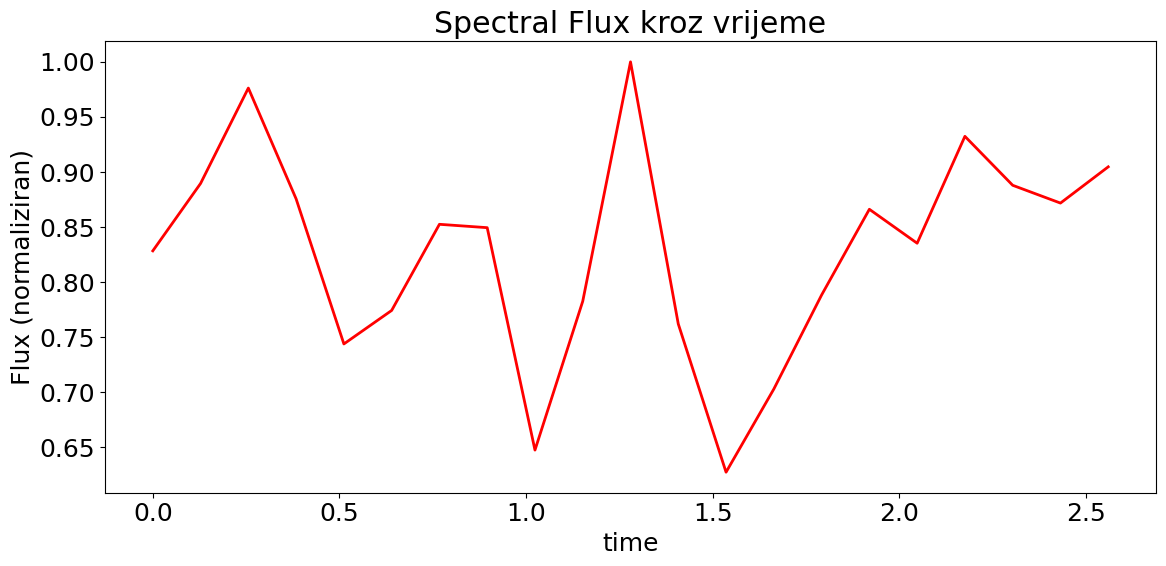

In [11]:
# spectral flux - koristi promjene u frekvencijama + amplitudu od osnovnih znacajki zvuka
window_size = 256
hop_size = 128
num_frames = int((len(f) - window_size) / hop_size)
spectral_flux = []

for i in range(num_frames):
    start = i * hop_size
    end = start + window_size
    
    frame1 = f[start:end]
    frame2 = f[start + hop_size:end + hop_size]
    
    # FFT za oba frame-a
    fft1 = np.abs(np.fft.fft(frame1))
    fft2 = np.abs(np.fft.fft(frame2))
    
    # uzmi samo pola spektra
    fft1 = fft1[:window_size//2]
    fft2 = fft2[:window_size//2]
    
    # razlika
    diff = fft2 - fft1
    
    # samo pozitivne promjene
    diff[diff < 0] = 0
    
    flux = np.sum(diff)
    spectral_flux.append(flux)

spectral_flux = np.array(spectral_flux)

# normalizacija 
spectral_flux = spectral_flux / np.max(spectral_flux)
time_flux = np.arange(len(spectral_flux)) * hop_size * dt


plt.figure(figsize=(12,6))
plt.plot(time_flux, spectral_flux, color='r', linewidth=2)
plt.title("Spectral Flux kroz vrijeme")
plt.xlabel("time")
plt.ylabel("Flux (normaliziran)")

plt.tight_layout()
plt.show()

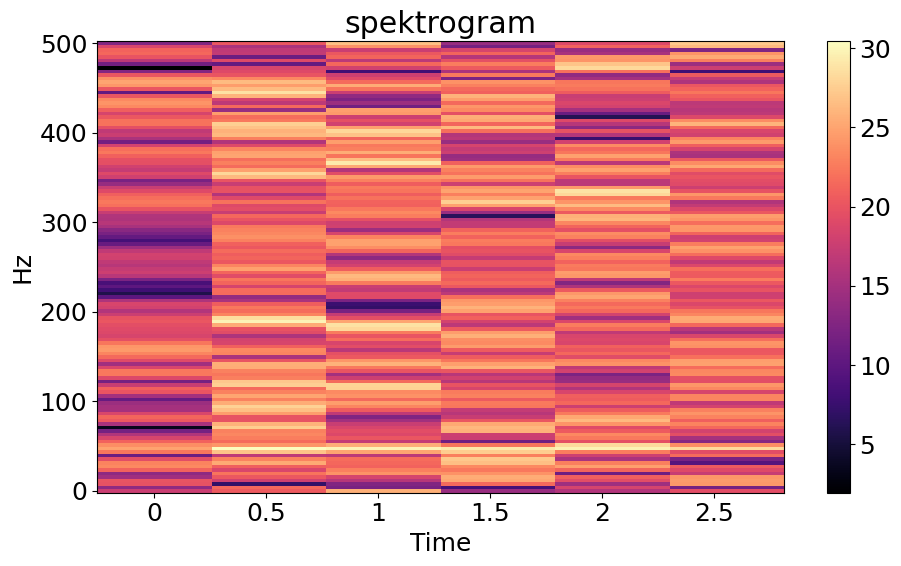

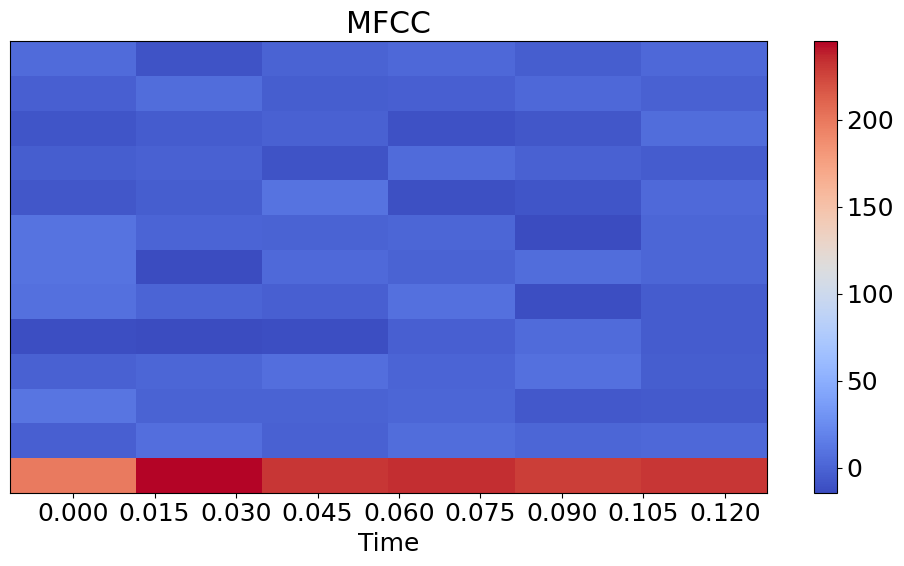

In [13]:
# Vizualizacija MFCC-a

import librosa
f_float = np.array(f, dtype=np.float32)  # Pretvaramo signal u float32
sr = int(1/dt)  # Sampling rate jer dt=0.001 --> fs = 1000 HzS = librosa.feature.melspectrogram(y=f_float, sr=sr, n_fft=256)
S = librosa.feature.melspectrogram(y=f_float, sr=sr, n_fft=256)
mfccs = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=13)


plt.figure(figsize=(10,6))
librosa.display.specshow(librosa.power_to_db(S), sr=sr, x_axis='time', y_axis='hz')
plt.title("spektrogram")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
librosa.display.specshow(mfccs, x_axis='time')
plt.title("MFCC")
plt.colorbar()
plt.tight_layout()
plt.show()